[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IbHansen/wb-debt-simulation/blob/main/optimization/currency.ipynb)

In [1]:
if 'google.colab' in str(get_ipython()):
    import os
    os.system('pip -qqq install ModelFlowIb')
    os.system('curl -L -o exchangerates_get.py https://raw.githubusercontent.com/IbHansen/wb-debt-simulation/main/optimization/exchangerates_get.py')

In [2]:
import pandas as pd
import numpy as np

import exchangerates_get as er

# Flip to True to force a fresh ECB download and overwrite the cache.
REFRESH = False

In [3]:
fx_eur = er.ecb_fx_eur(
    currencies=["USD", "GBP", "JPY", "CHF","EUR","ZAR"],
    start="2010-01-01",
    freq='Q',
    refresh=REFRESH,
)
#fx_eur    

CURRENCY,EUR_CHF,EUR_GBP,EUR_JPY,EUR_USD,EUR_ZAR,EUR_EUR
TIME_PERIOD,,,,,,
2010Q1,1.4276,0.88980,125.93,1.3479,9.8922,1.0
2010Q2,1.3283,0.81745,108.79,1.2271,9.3808,1.0
2010Q3,1.3287,0.85995,113.68,1.3648,9.5438,1.0
2010Q4,1.2504,0.86075,108.65,1.3362,8.8625,1.0
2011Q1,1.3005,0.88370,117.61,1.4207,9.6507,1.0
...,...,...,...,...,...,...
2025Q2,0.9347,0.85550,169.17,1.1720,20.8411,1.0
2025Q3,0.9364,0.87340,173.76,1.1741,20.2820,1.0
2025Q4,0.9314,0.87260,184.09,1.1750,19.4439,1.0


In [4]:
# Step 2: express everything in base currency 
fx_ccy = er.convert_base_currency(fx_eur, base="zar")

fx_returns = er.get_fx_returns(fx_ccy)
# Step 3: yearly covariance matrices
fx_cov = er.get_fx_covariance(fx_returns)

In [5]:
fx_corr = er.get_fx_covariance(fx_returns,correlation=True)
# Example: covariance matrix and standard deviation  
display(fx_cov)

,ZAR_CHF,ZAR_GBP,ZAR_JPY,ZAR_USD,ZAR_EUR
ZAR_CHF,0.003287,0.002610,0.003119,0.003125,0.002813
ZAR_GBP,0.002610,0.003109,0.002854,0.003047,0.002742
ZAR_JPY,0.003119,0.002854,0.005354,0.003598,0.002857
ZAR_USD,0.003125,0.003047,0.003598,0.004665,0.002921
ZAR_EUR,0.002813,0.002742,0.002857,0.002921,0.003189


ZAR_CHF    5.733496
ZAR_GBP    5.575436
ZAR_JPY    7.317355
ZAR_USD    6.830069
ZAR_EUR    5.646906
Name: std, dtype: float64


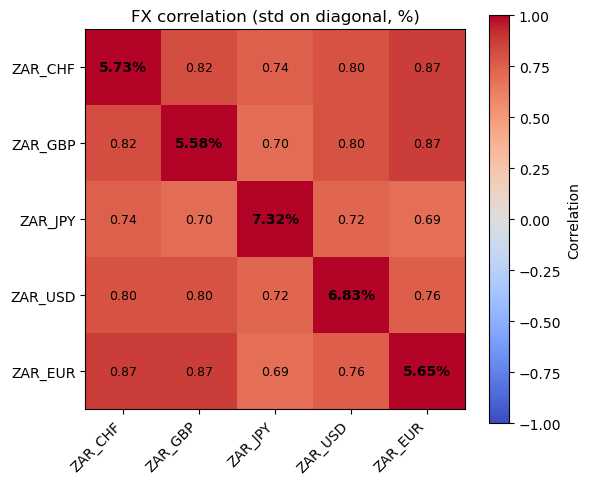

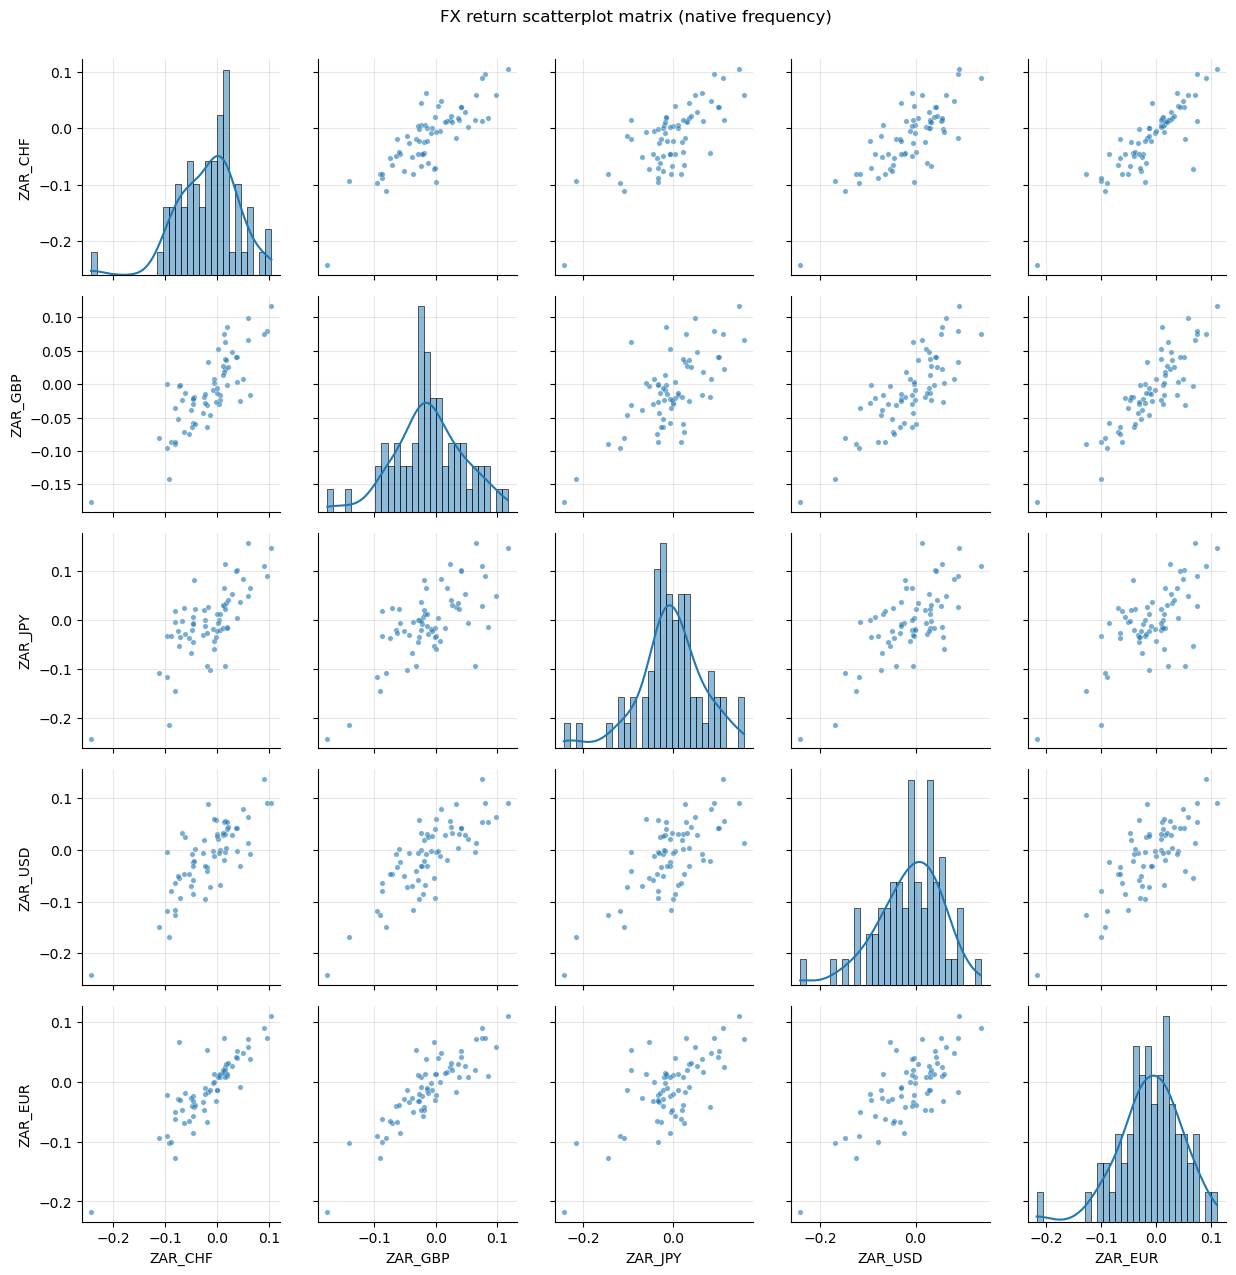

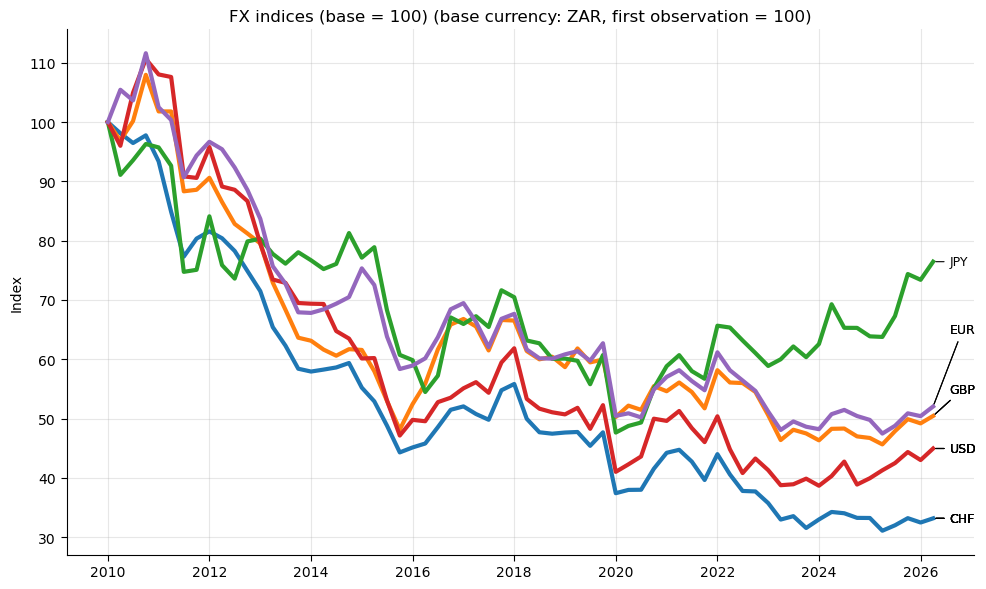

In [11]:
print(std*100)

er.plot_corr_with_std(
    fx_returns,
    title="FX correlation (std on diagonal, %)"
)


er.plot_return_scatter_matrix_with_marginals(
    fx_returns,
    title="FX return scatterplot matrix (native frequency)"
)
#%%
er.plot_indexed_fx(
    fx_ccy,
    min_label_gap=10.0

)

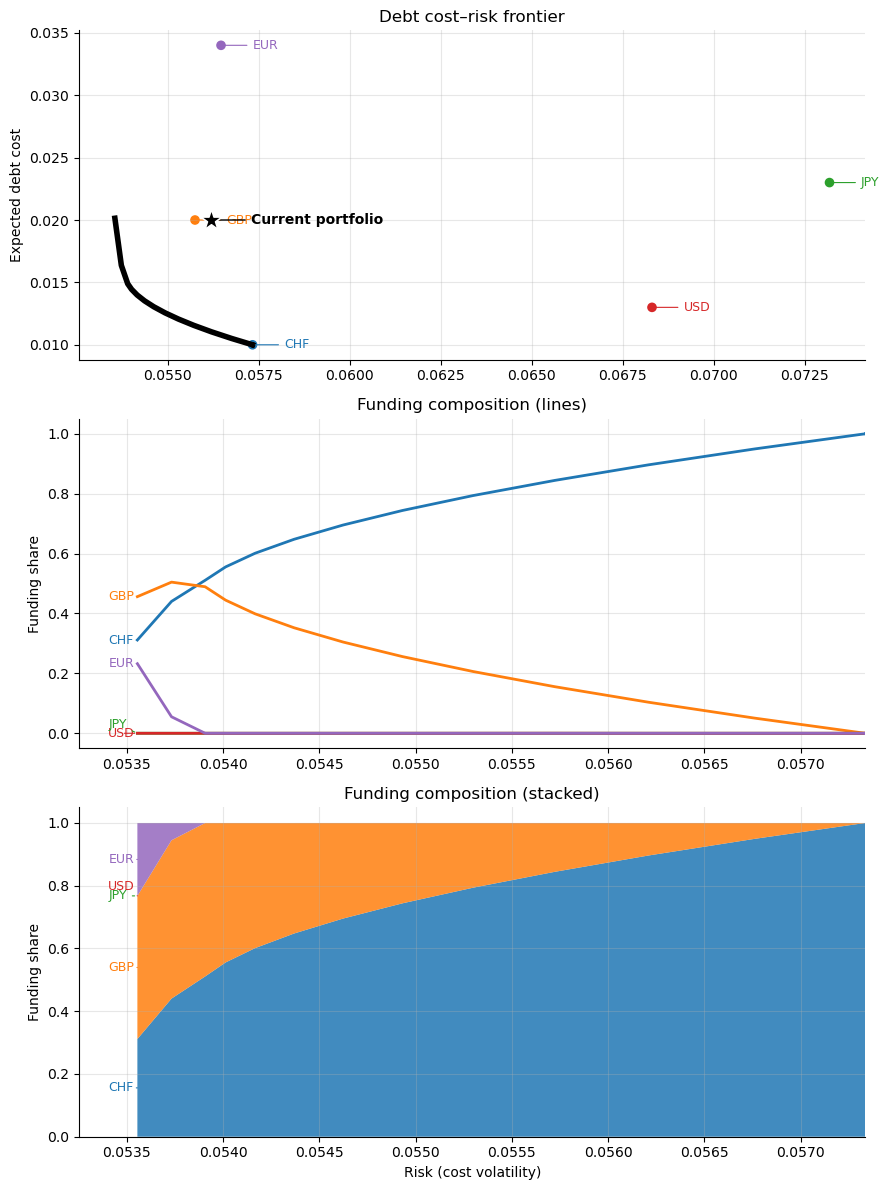

In [7]:
cov_df = fx_cov.rename(
    index=lambda x: x.split('_')[1],
    columns=lambda x: x.split('_')[1],
)
names = cov_df.index

assumptions = pd.DataFrame(
    {
        'interest_rate':         [0.010, 0.020, 0.023, 0.013, 0.034],
        'expected_appreciation': [0.000, 0.000, 0.000, 0.000, 0.000],
        'min_share':             [0.0, 0.0, 0.0, 0.0, 0.0],
        'max_share':             [1.0, 1.0, 1.0, 1.0, 1.0],
        'current_share':         [0.2, 0.2, 0.2, 0.2, 0.2],
    },
    index=names,
)

res = er.mv_from_dataframes(cov_df=cov_df, assumptions=assumptions)

# row 0 = current composition; rows 1: = frontier
expected_cost = assumptions['interest_rate'] + assumptions['expected_appreciation']

er.plot_debt_frontier_labeled(
    res.iloc[1:].reset_index(drop=True),
    label_pos="start",
    cost_col="return",
    cost_s=expected_cost,
    cov_df=cov_df,
    current=res.iloc[0],
    export_path="zar_debt_frontier",
    export_formats=("png", "pdf", "svg"),
)


In [8]:
res


,risk,return,CHF,GBP,JPY,USD,EUR
0,0.056206,0.020000,0.200000,2.000000e-01,2.000000e-01,0.200000,2.000000e-01
1,0.053555,0.020139,0.311384,4.562049e-01,9.724175e-05,0.000002,2.323122e-01
2,0.053733,0.016368,0.440271,5.046705e-01,1.574705e-05,0.000002,5.504118e-02
3,0.053907,0.014892,0.510765,4.892252e-01,5.277675e-06,0.000002,2.548572e-06
4,0.054013,0.014445,0.555491,4.445020e-01,2.955416e-06,0.000004,2.878071e-07
...,...,...,...,...,...,...,...
97,0.057335,0.010000,0.999998,2.148045e-08,3.007027e-08,0.000002,3.442535e-08
98,0.057335,0.010000,0.999998,2.134532e-08,2.983921e-08,0.000002,3.382842e-08
99,0.057335,0.010000,0.999998,2.120185e-08,2.957649e-08,0.000002,3.320054e-08
100,0.057335,0.010000,0.999998,2.105008e-08,2.928310e-08,0.000002,3.254351e-08


## Interactive inputs — `DebtFrontierInputs`

The cells below wrap the same covariance matrix and assumption frame in a `DebtFrontierInputs` dataclass and render an editable grid (currencies × input fields). Edit any cell, then press **Run frontier** to re-solve and re-plot. The dataclass's `assumptions` attribute always reflects the latest edits, so you can also drive `inputs.plot()` from code between clicks.

In [9]:
inputs = er.DebtFrontierInputs(cov_df=cov_df, assumptions=assumptions)
inputs.assumptions

,interest_rate,expected_appreciation,min_share,max_share,current_share
CHF,0.010,0.0,0.0,1.0,0.2
GBP,0.020,0.0,0.0,1.0,0.2
JPY,0.023,0.0,0.0,1.0,0.2
USD,0.013,0.0,0.0,1.0,0.2
EUR,0.034,0.0,0.0,1.0,0.2


In [10]:
inputs.widget()